# 상권 정보 데이터 수집

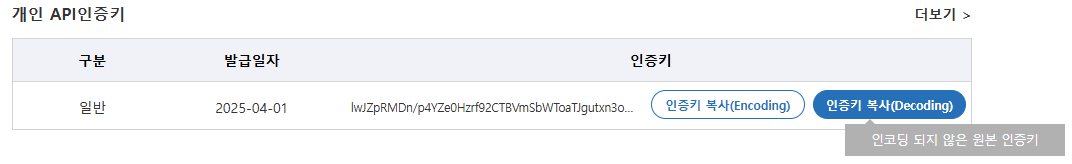
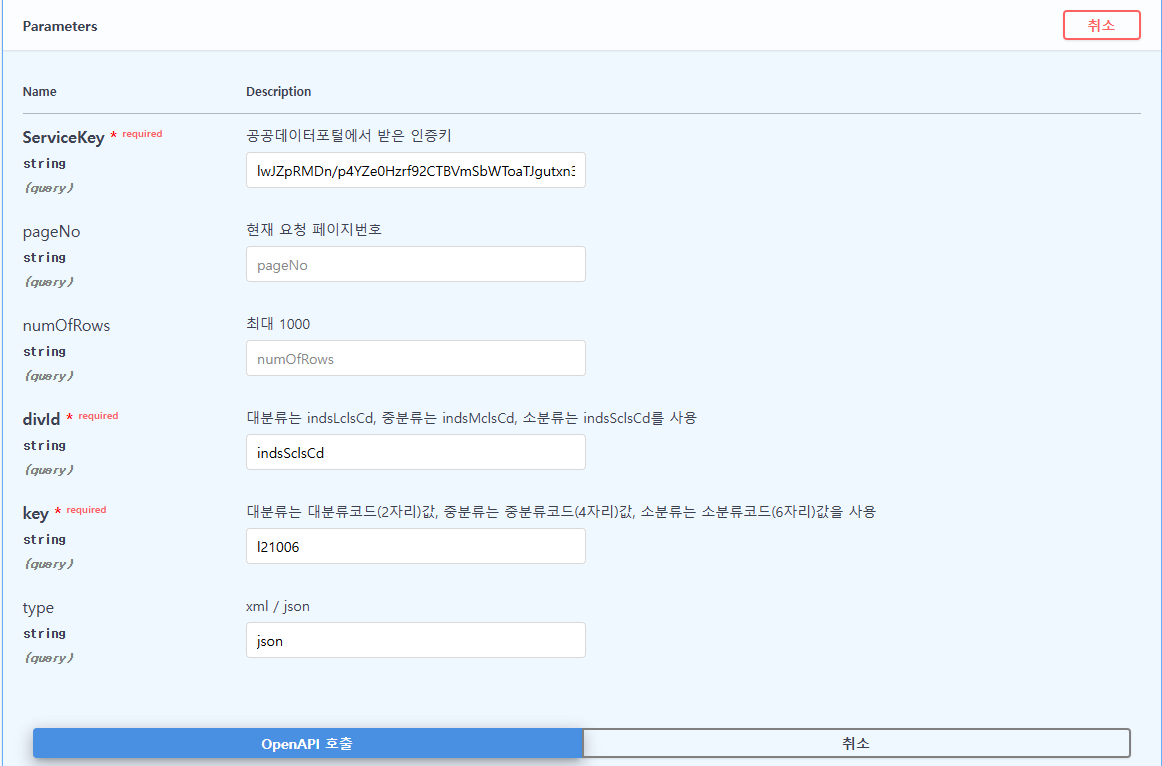

In [1]:
import requests
import pandas as pd
import json

In [ ]:
def unpack_data(data):
    result = {}
    for item in data['body']['items']:
        for key, value in zip(data['header']['columns'],item.values()):
            result.setdefault(key,[]).append(value)
    df = pd.DataFrame(result)

1. 한 리스트에 unpack한 데이터를 append 후 한번에 데이터프레임으로 바꾸기
2. 하나의 딕셔너리에 계속 추가하여 데이터프레임으로 바꾸기

<hr>

1. total 값 찾은 후 반복문 돌리기 <br>
2. while True 후 page > total_page인 경우 break 걸기

In [16]:
import requests
import pandas as pd
import json

store_dic = {}
i = 1

while i <= 43:
    url = "http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong"
    payload = {'servicekey' : "lwJZpRMDn/p4YZe0Hzrf92CTBVmSbWToaTJgutxn3oJ6kss3RSoaZtwPvQiQLKYowcKSOnj3h6G54NvRysgQGA==", 
               'divId': 'indsSclsCd', 
               'key': 'I21006', 
               'numOfRows' : 1000, 
               'pageNo' : i,
               'type': 'json'}  

    r = requests.get(url, params=payload)

    data = r.json()

    for item in data['body']['items']:
        for key, value in zip(data['header']['columns'],item.values()):
            store_dic.setdefault(key,[]).append(value)
    
    i += 1
        
        
store_df = pd.DataFrame(store_dic)
store_df.to_csv("store_list")

In [12]:
data['body'].keys()

dict_keys(['items', 'numOfRows', 'pageNo', 'totalCount'])

In [6]:
data['body']['totalCount']

42095

In [14]:
data['header']['columns']

['상가업소번호',
 '상호명',
 '지점명',
 '상권업종대분류코드',
 '상권업종대분류명',
 '상권업종중분류코드',
 '상권업종중분류명',
 '상권업종소분류코드',
 '상권업종소분류명',
 '표준산업분류코드',
 '표준산업분류명',
 '시도코드',
 '시도명',
 '시군구코드',
 '시군구명',
 '행정동코드',
 '행정동명',
 '법정동코드',
 '법정동명',
 'PNU코드',
 '대지구분코드',
 '대지구분명',
 '지번본번지',
 '지번부번지',
 '지번주소',
 '도로명코드',
 '도로명',
 '건물본번지',
 '건물부번지',
 '건물관리번호',
 '건물명',
 '도로명주소',
 '구우편번호',
 '신우편번호',
 '동정보',
 '층정보',
 '호정보',
 '경도',
 '위도']

In [17]:
!pip install openpyxl

In [34]:
ori_data = pd.read_excel('./data/소상공인시장진흥공단_상가(상권)정보_업종분류(2302)_및_연계표_v1.0.xlsx', engine = 'openpyxl', header=[0])

In [35]:
ori_data

,상가(상권)정보 업종분류(247개),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,대분류코드,대분류명,중분류코드,중분류명,소분류코드,소분류명
1,G2,소매업,G202,자동차 부품 및 내장품 소매업,G20201,타이어 소매업
2,G2,소매업,G202,자동차 부품 및 내장품 소매업,G20202,자동차 부품 소매업
3,G2,소매업,G203,모터사이클 및 부품 소매업,G20301,모터사이클 및 부품 소매업
4,G2,소매업,G204,종합 소매업,G20404,슈퍼마켓
...,...,...,...,...,...,...
243,S2,수리 및 개인 서비스업,S209,세탁업,S20902,셀프 빨래방
244,S2,수리 및 개인 서비스업,S210,장례식장 및 관련 서비스업,S21001,장례식장
245,S2,수리 및 개인 서비스업,S210,장례식장 및 관련 서비스업,S21002,화장터/묘지/납골당
246,S2,수리 및 개인 서비스업,S211,기타 개인서비스,S21101,예식장업


In [36]:
ori_data2 = pd.read_excel('./data/소상공인시장진흥공단_상가(상권)정보_업종분류(2302)_및_연계표_v1.0.xlsx', engine = 'openpyxl', header=[1])

In [37]:
ori_data2

,대분류코드,대분류명,중분류코드,중분류명,소분류코드,소분류명
0,G2,소매업,G202,자동차 부품 및 내장품 소매업,G20201,타이어 소매업
1,G2,소매업,G202,자동차 부품 및 내장품 소매업,G20202,자동차 부품 소매업
2,G2,소매업,G203,모터사이클 및 부품 소매업,G20301,모터사이클 및 부품 소매업
3,G2,소매업,G204,종합 소매업,G20404,슈퍼마켓
4,G2,소매업,G204,종합 소매업,G20405,편의점
...,...,...,...,...,...,...
242,S2,수리 및 개인 서비스업,S209,세탁업,S20902,셀프 빨래방
243,S2,수리 및 개인 서비스업,S210,장례식장 및 관련 서비스업,S21001,장례식장
244,S2,수리 및 개인 서비스업,S210,장례식장 및 관련 서비스업,S21002,화장터/묘지/납골당
245,S2,수리 및 개인 서비스업,S211,기타 개인서비스,S21101,예식장업


In [29]:
code = list(ori_data['소분류코드'])
code

['G20201',
 'G20202',
 'G20301',
 'G20404',
 'G20405',
 'G20499',
 'G20501',
 'G20502',
 'G20503',
 'G20504',
 'G20505',
 'G20506',
 'G20507',
 'G20508',
 'G20509',
 'G20601',
 'G20602',
 'G20603',
 'G20604',
 'G20701',
 'G20801',
 'G20802',
 'G20803',
 'G20901',
 'G20902',
 'G20903',
 'G20904',
 'G20905',
 'G20906',
 'G20907',
 'G20908',
 'G20909',
 'G20910',
 'G20911',
 'G21001',
 'G21002',
 'G21003',
 'G21099',
 'G21101',
 'G21201',
 'G21202',
 'G21203',
 'G21301',
 'G21302',
 'G21303',
 'G21304',
 'G21305',
 'G21306',
 'G21401',
 'G21402',
 'G21403',
 'G21501',
 'G21502',
 'G21503',
 'G21601',
 'G21602',
 'G21603',
 'G21701',
 'G21801',
 'G21802',
 'G21901',
 'G22001',
 'G22199',
 'G22201',
 'I10101',
 'I10102',
 'I10103',
 'I10104',
 'I10201',
 'I10299',
 'I20101',
 'I20102',
 'I20103',
 'I20104',
 'I20105',
 'I20106',
 'I20107',
 'I20108',
 'I20109',
 'I20110',
 'I20111',
 'I20112',
 'I20113',
 'I20199',
 'I20201',
 'I20202',
 'I20301',
 'I20302',
 'I20303',
 'I20399',
 'I20401',